# Proyek Akhir: Prediksi Dropout Mahasiswa (Jaya Jaya Institut)

- Nama: Jaya Jaya Student Analytics Team
- Email: student.analytics@jayajaya.ac.id
- Id Dicoding: b_igloo

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

### Menyiapkan data yang akan digunakan

In [2]:
df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [3]:
print('Struktur Dataset:', df.shape)
print('Total Missing Values:', df.isnull().sum().sum())
df.info()

Struktur Dataset: (4424, 37)
Total Missing Values: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qu

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_41092\4107831793.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', palette='Set2')


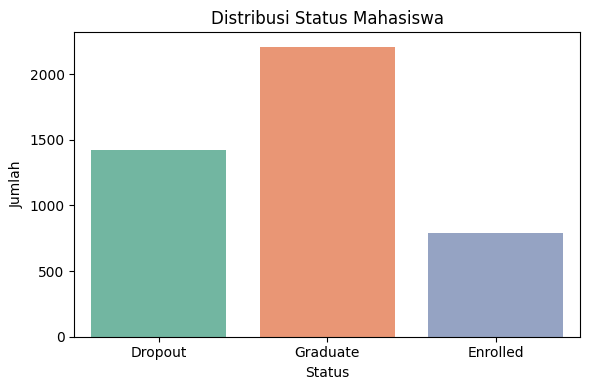

In [4]:
# Distribusi Status Mahasiswa
status_counts = df['Status'].value_counts()
print(status_counts)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Status', palette='Set2')
plt.title('Distribusi Status Mahasiswa')
plt.xlabel('Status')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

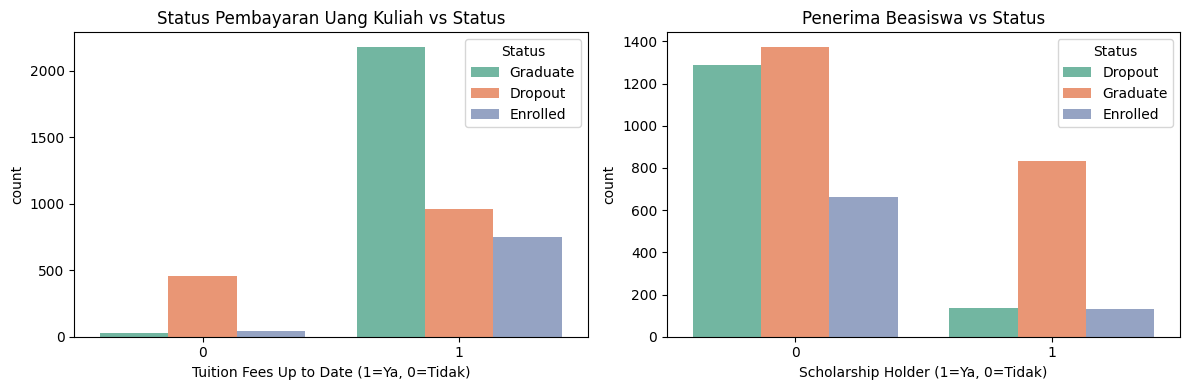

In [5]:
# Hubungan Status Finansial dengan Dropout
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='Tuition_fees_up_to_date', hue='Status', ax=axes[0], palette='Set2')
axes[0].set_title('Status Pembayaran Uang Kuliah vs Status')
axes[0].set_xlabel('Tuition Fees Up to Date (1=Ya, 0=Tidak)')

sns.countplot(data=df, x='Scholarship_holder', hue='Status', ax=axes[1], palette='Set2')
axes[1].set_title('Penerima Beasiswa vs Status')
axes[1].set_xlabel('Scholarship Holder (1=Ya, 0=Tidak)')

plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_41092\313213751.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_grade', ax=axes[0], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_41092\313213751.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_grade', ax=axes[1], palette='Set2')


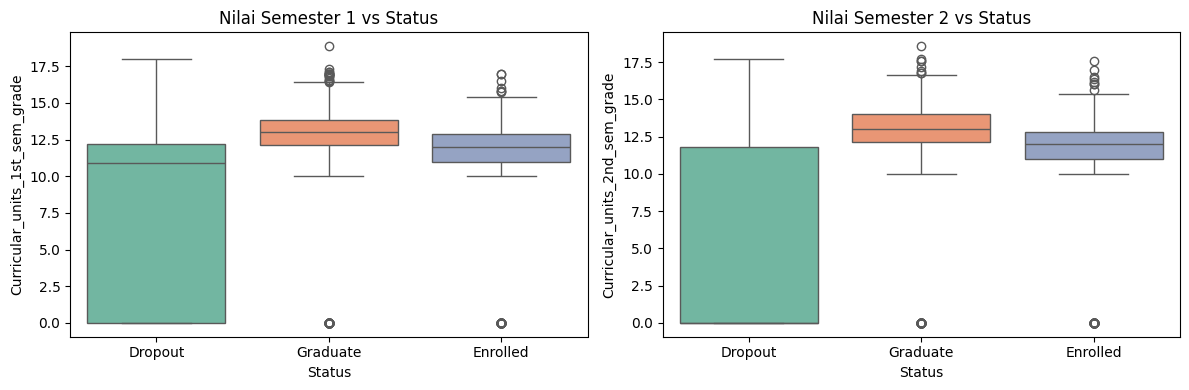

In [6]:
# Hubungan Performa Akademik Semester 1 & 2 dengan Status
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_grade', ax=axes[0], palette='Set2')
axes[0].set_title('Nilai Semester 1 vs Status')

sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_grade', ax=axes[1], palette='Set2')
axes[1].set_title('Nilai Semester 2 vs Status')

plt.tight_layout()
plt.show()

## Data Preparation / Preprocessing

In [7]:
# Pembuatan target biner: 1 untuk Dropout, 0 untuk Non-Dropout (Graduate & Enrolled)
X = df.drop(columns=['Status'])
y = (df['Status'] == 'Dropout').astype(int)

print('Distribusi Target Biner:')
print(y.value_counts(normalize=True))

Distribusi Target Biner:
Status
0    0.678797
1    0.321203
Name: proportion, dtype: float64


In [8]:
# Split dataset train dan test (80:20) dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Dimensi X_train:', X_train.shape)
print('Dimensi X_test:', X_test.shape)

Dimensi X_train: (3539, 36)
Dimensi X_test: (885, 36)


In [9]:
# Standarisasi fitur menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling

In [10]:
# Model 1: Logistic Regression (Baseline)
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_scaled, y_train)

# Model 2: Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Evaluation

In [11]:
# Evaluasi Logistic Regression
y_pred_lr = model_lr.predict(X_test_scaled)
print('=== Evaluasi Logistic Regression ===')
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print('Recall (Dropout):', recall_score(y_test, y_pred_lr))
print('F1-Score (Dropout):', f1_score(y_test, y_pred_lr))
print('\nClassification Report:\n', classification_report(y_test, y_pred_lr))

=== Evaluasi Logistic Regression ===
Accuracy: 0.8858757062146893
Recall (Dropout): 0.7359154929577465
F1-Score (Dropout): 0.8053949903660886

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92       601
           1       0.89      0.74      0.81       284

    accuracy                           0.89       885
   macro avg       0.89      0.85      0.86       885
weighted avg       0.89      0.89      0.88       885



In [12]:
# Evaluasi Random Forest
y_pred_rf = model_rf.predict(X_test)
print('=== Evaluasi Random Forest ===')
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Recall (Dropout):', recall_score(y_test, y_pred_rf))
print('F1-Score (Dropout):', f1_score(y_test, y_pred_rf))
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))

=== Evaluasi Random Forest ===
Accuracy: 0.8824858757062147
Recall (Dropout): 0.7253521126760564
F1-Score (Dropout): 0.7984496124031008

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92       601
           1       0.89      0.73      0.80       284

    accuracy                           0.88       885
   macro avg       0.88      0.84      0.86       885
weighted avg       0.88      0.88      0.88       885



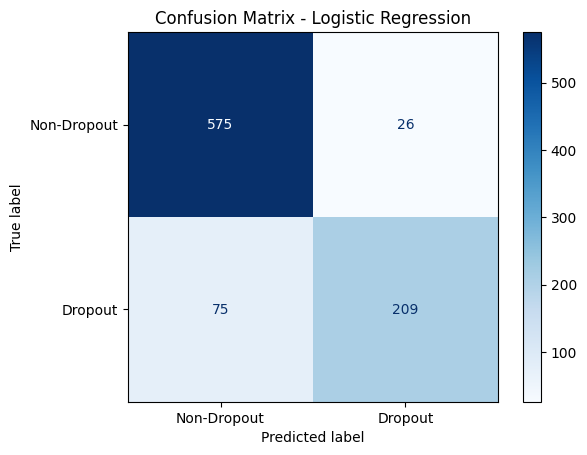

In [13]:
# Visualisasi Confusion Matrix Model Terbaik (Logistic Regression)
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Dropout', 'Dropout'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [14]:
# Menyimpan model terbaik, scaler, dan daftar fitur untuk prototype Streamlit
os.makedirs('model', exist_ok=True)
joblib.dump(model_lr, 'model/model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')
joblib.dump(list(X.columns), 'model/features.pkl')
print('Model dan artefak berhasil disimpan di folder model/.')

Model dan artefak berhasil disimpan di folder model/.
